# DINOv2 Feature Extraction for Fleuron Candidates

In this notebook we convert candidate crops into numerical representations for similarity search and clustering. Each output row stays linked to one crop through a row-aligned manifest.

Our corpus contains both bitonal scans and continuous-tone scans. To reduce the influence of paper colour and scanning modality, we convert each crop to grayscale and binarise it independently with Otsu before encoding it with DINOv2 ViT-B/14. We pad the crop to a square canvas rather than stretching it, resize to `224 × 224`, and normalise with ImageNet statistics.

We embed crops whose shorter side is at least 24 pixels. This practical filter removes many very small or thin connected components before representation learning; the excluded rows remain available in the candidate manifest.

```text
Candidate crop manifest (30,804 RGB crops)
        ↓
1_FeatureExtraction.ipynb  (filters to min_side >= 24px, then embeds)
        ↓ 21,750 x 768-dimensional DINOv2 vectors
2_PairBenchmark.ipynb
```

---

**Reads** `all_regions_outputs/crops/` · **Writes** `feature_extraction_outputs/<run>/` · **Chapter README** §2

## Which crops are clustered

The input is the earlier Otsu extraction (the same method with slightly different parameters:
Gaussian 5 / area 80 / pad 3) rather than the later frozen run of 40,397 crops (Gaussian 3 /
area 40 / pad 3). Switching would invalidate roughly 330 existing human labels. The comparison
immediately below measures the cost of that decision against the frozen run and finds the overlap
to be 98.8%, so the practical effect on this chapter's input is small.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

_check_project_dir = Path.cwd().resolve().parent   # the notebook runs from 2_clustering/

old_boxes = pd.read_csv(_check_project_dir / 'all_regions_outputs' / 'candidate_boxes.csv')
frozen_boxes = pd.read_csv(
    _check_project_dir / '1_segmentation_outputs' / 'otsu_g3_area40_pad3_v1' / 'candidate_boxes.csv'
)
clustering_manifest = pd.read_csv(
    _check_project_dir / 'feature_extraction_outputs'
    / 'all_regions_v1_minside24_dinov2_vitb14_binarized_v1' / 'features_manifest.csv'
)

clustered_keys = set(zip(clustering_manifest.stem, clustering_manifest.candidate_id))
old_boxes['used_in_clustering'] = list(zip(old_boxes.stem, old_boxes.candidate_id))
old_boxes['used_in_clustering'] = old_boxes['used_in_clustering'].isin(clustered_keys)
assert old_boxes.used_in_clustering.sum() == len(clustering_manifest)


def box_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    return inter / (area_a + area_b - inter)


IOU_THRESHOLD = 0.5
old_matched = np.zeros(len(old_boxes), dtype=bool)
frozen_matched = np.zeros(len(frozen_boxes), dtype=bool)

for stem, old_scan in old_boxes.groupby('stem'):
    frozen_scan = frozen_boxes[frozen_boxes.stem == stem]
    if frozen_scan.empty:
        continue
    o_xy = old_scan[['x_min', 'y_min', 'x_max', 'y_max']].to_numpy()
    f_xy = frozen_scan[['x_min', 'y_min', 'x_max', 'y_max']].to_numpy()
    o_idx, f_idx = old_scan.index.to_numpy(), frozen_scan.index.to_numpy()

    candidate_pairs = sorted(
        (
            (box_iou(o_xy[i], f_xy[j]), i, j)
            for i in range(len(o_xy)) for j in range(len(f_xy))
            if box_iou(o_xy[i], f_xy[j]) >= IOU_THRESHOLD
        ),
        reverse=True,
    )
    taken_o, taken_f = set(), set()
    for _, i, j in candidate_pairs:
        if i in taken_o or j in taken_f:
            continue
        taken_o.add(i)
        taken_f.add(j)
        old_matched[o_idx[i]] = True
        frozen_matched[f_idx[j]] = True

old_boxes['matched_to_frozen_config'] = old_matched
frozen_boxes['matched_to_our_config'] = frozen_matched
frozen_boxes['min_side'] = frozen_boxes[['width', 'height']].min(axis=1)

clustered = old_boxes[old_boxes.used_in_clustering]
frozen_only = frozen_boxes[~frozen_boxes.matched_to_our_config]

print(f'Clustered crops present in the frozen config: {clustered.matched_to_frozen_config.mean():.1%} '
      f'({clustered.matched_to_frozen_config.sum():,} / {len(clustering_manifest):,})')
print(f'Frozen-only additions below MIN_SIDE>=24 (would be filtered anyway): '
      f'{(frozen_only.min_side < 24).mean():.1%}')

MISMATCH_PATH = Path.cwd() / 'segmentation_config_mismatch_check.csv'
pd.DataFrame([{
    'our_extraction_total': len(old_boxes),
    'frozen_extraction_total': len(frozen_boxes),
    'clustering_input': len(clustering_manifest),
    'clustered_crops_present_in_frozen_config': int(clustered.matched_to_frozen_config.sum()),
    'clustered_crops_absent_from_frozen_config': int((~clustered.matched_to_frozen_config).sum()),
    'frozen_only_boxes_below_minside24': int((frozen_only.min_side < 24).sum()),
    'frozen_only_boxes_at_or_above_minside24': int((frozen_only.min_side >= 24).sum()),
}]).to_csv(MISMATCH_PATH, index=False)


Clustered crops present in the frozen config: 98.8% (21,489 / 21,750)
Frozen-only additions below MIN_SIDE>=24 (would be filtered anyway): 90.5%


98.8% of the 21,750 clustered crops have a counterpart in the frozen configuration, and most of
what that configuration adds beyond them is sub-24-pixel material the feature stage would discard in
any case. The 21,750-crop set is therefore carried forward below.

## 1. Configuration and input validation


In [2]:
import hashlib
import json
import os
import time
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# the DINOv2 hub model emits three UserWarnings reporting that the optional xFormers
# kernels are unavailable; they concern speed, not the embeddings, and are the only
# warnings this notebook silences
warnings.filterwarnings('ignore', message='xFormers is not available')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '2_clustering', 'Run this notebook from its own folder, 2_clustering/.'
PROJECT_DIR = NOTEBOOK_DIR.parent
assert (PROJECT_DIR / 'all_regions_outputs').exists(), (
    f'Missing all_regions_outputs/ next to {NOTEBOOK_DIR.name}/.'
)
# ---------------------------------------------------------------------------
# Output versioning.
#   RUN_TAG = ''          reproduces the frozen thesis run (read-only guard on)
#   RUN_TAG = '_rerun1'   writes to a parallel directory, leaving the frozen
#                         artifacts untouched
# Input paths always point at the frozen artifacts, so a re-run is reproducible
# rather than self-referential.
# ---------------------------------------------------------------------------
RUN_TAG = '_rerun1'
ALLOW_OVERWRITE = False


def guarded_mkdir(path):
    """Create an output directory, refusing to overwrite a populated one."""
    if path.exists() and any(path.iterdir()) and not (RUN_TAG or ALLOW_OVERWRITE):
        raise RuntimeError(
            f'{path} already contains results. Set RUN_TAG to write elsewhere, '
            f'or ALLOW_OVERWRITE = True to replace them.')
    path.mkdir(parents=True, exist_ok=True)
    return path

INPUT_RUN_ID = 'all_regions_v1'
INPUT_DIR = PROJECT_DIR / 'all_regions_outputs'
INPUT_MANIFEST_PATH = INPUT_DIR / 'crops_manifest.csv'
assert INPUT_MANIFEST_PATH.exists()

MODEL_NAME = 'dinov2_vitb14'
MODEL_DIMENSION = 768
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0
MIN_SIDE = 24
BINARIZE = True
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

OUTPUT_RUN_ID = f'{INPUT_RUN_ID}_minside{MIN_SIDE}_{MODEL_NAME}_binarized_v1'
OUTPUT_DIR = PROJECT_DIR / 'feature_extraction_outputs' / (OUTPUT_RUN_ID + RUN_TAG)
FIGURES_DIR = OUTPUT_DIR / 'figures'
FEATURES_PATH = OUTPUT_DIR / 'dino_features_binarized.npy'
FEATURE_MANIFEST_PATH = OUTPUT_DIR / 'features_manifest.csv'
PROGRESS_PATH = OUTPUT_DIR / 'embedding_progress.json'
METADATA_PATH = OUTPUT_DIR / 'embedding_metadata.json'
SUMMARY_PATH = OUTPUT_DIR / 'embedding_summary.csv'
FORMAT_DIAGNOSTIC_PATH = OUTPUT_DIR / 'format_diagnostic.csv'
UMAP_PATH = OUTPUT_DIR / 'umap_2d.npy'

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def sha256_file(file_path: Path) -> str:
    digest = hashlib.sha256()
    with file_path.open('rb') as file_handle:
        for chunk in iter(lambda: file_handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


input_manifest_sha256 = sha256_file(INPUT_MANIFEST_PATH)

print('Input manifest :', INPUT_MANIFEST_PATH)
print('Output folder  :', OUTPUT_DIR)
print('Model          :', MODEL_NAME)
print('Device         :', DEVICE)
print('Batch size     :', BATCH_SIZE)


Input manifest : <project>/all_regions_outputs/crops_manifest.csv
Output folder  : <project>/feature_extraction_outputs/all_regions_v1_minside24_dinov2_vitb14_binarized_v1_rerun1
Model          : dinov2_vitb14
Device         : cuda
Batch size     : 64


## 2. Prepare the row-aligned feature manifest

We fix the feature index before inference. The row at index `i` in `features_manifest.csv` always describes row `i` in `dino_features_binarized.npy`.


In [3]:
candidate_manifest = pd.read_csv(INPUT_MANIFEST_PATH)
candidate_manifest['crop_path'] = candidate_manifest.crop_path.astype(str)
candidate_manifest['min_side'] = candidate_manifest[['width', 'height']].min(axis=1)
candidate_manifest['crop_exists'] = candidate_manifest.crop_path.map(
    lambda value: (PROJECT_DIR / value).exists()
)
assert candidate_manifest.crop_exists.all(), 'At least one candidate crop is missing.'
assert not candidate_manifest.duplicated(['source', 'stem', 'candidate_id']).any()

features_manifest = (
    candidate_manifest[candidate_manifest.min_side >= MIN_SIDE]
    .drop(columns='crop_exists')
    .reset_index(drop=True)
)
features_manifest.insert(0, 'feature_index', np.arange(len(features_manifest), dtype=int))
assert len(features_manifest) > 0

embedding_protocol = {
    'pipeline': 'fleuron_feature_extraction',
    'pipeline_version': 1,
    'notebook': '1_FeatureExtraction.ipynb',
    'output_run_id': OUTPUT_RUN_ID,
    'input_run_id': INPUT_RUN_ID,
    'input_manifest_sha256': input_manifest_sha256,
    'input_rows': int(len(features_manifest)),
    'model_name': MODEL_NAME,
    'model_dimension': MODEL_DIMENSION,
    'image_size': IMAGE_SIZE,
    'binarize_per_crop': BINARIZE,
    'square_padding': 'white',
    'resize': 'bicubic',
    'normalization': 'ImageNet mean/std',
    'minimum_crop_side': MIN_SIDE,
    'random_seed': RANDOM_SEED,
}

guarded_mkdir(OUTPUT_DIR)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
if FEATURE_MANIFEST_PATH.exists():
    existing_manifest = pd.read_csv(FEATURE_MANIFEST_PATH)
    assert existing_manifest[['feature_index', 'crop_path']].equals(
        features_manifest[['feature_index', 'crop_path']]
    )
else:
    features_manifest.to_csv(FEATURE_MANIFEST_PATH, index=False)

print(f'Candidates prepared for embedding: {len(features_manifest):,}')
print(f'Candidates excluded by size: {len(candidate_manifest) - len(features_manifest):,}')
print('Minimum crop side:', int(features_manifest.min_side.min()))
display(features_manifest.head())


Candidates prepared for embedding: 21,750
Candidates excluded by size: 9,054
Minimum crop side: 24


,feature_index,filename,source,rel_path,stem,candidate_id,n_candidates,x_min,y_min,x_max,y_max,width,height,area,area_ratio,crop_path,min_side
0,0,"Oxprlava57.t1,163.bmp",original,"Oxprlava57.t1,163.bmp","Oxprlava57.t1,163",0,8,4,3,221,162,217,159,10152,0.076242,"all_regions_outputs/crops/Oxprlava57.t1,163/Ox...",159
1,1,"Oxprlava57.t1,163.bmp",original,"Oxprlava57.t1,163.bmp","Oxprlava57.t1,163",1,8,267,9,491,161,224,152,10035,0.075363,"all_regions_outputs/crops/Oxprlava57.t1,163/Ox...",152
2,2,"Oxprlava57.t1,163.bmp",original,"Oxprlava57.t1,163.bmp","Oxprlava57.t1,163",2,8,251,110,283,151,32,41,509,0.003823,"all_regions_outputs/crops/Oxprlava57.t1,163/Ox...",32
3,3,"Oxprlava57.t1,163.bmp",original,"Oxprlava57.t1,163.bmp","Oxprlava57.t1,163",3,8,215,111,243,136,28,25,272,0.002043,"all_regions_outputs/crops/Oxprlava57.t1,163/Ox...",25
4,4,"Oxprlava57.t1,163.bmp",original,"Oxprlava57.t1,163.bmp","Oxprlava57.t1,163",4,8,0,142,29,173,29,31,302,0.002268,"all_regions_outputs/crops/Oxprlava57.t1,163/Ox...",29


## 3. Per-crop preprocessing

Per-crop Otsu removes paper tone while keeping a black-ink/white-paper representation. We pad to a square rather than stretching, since stretching would geometrically distort the fleuron.


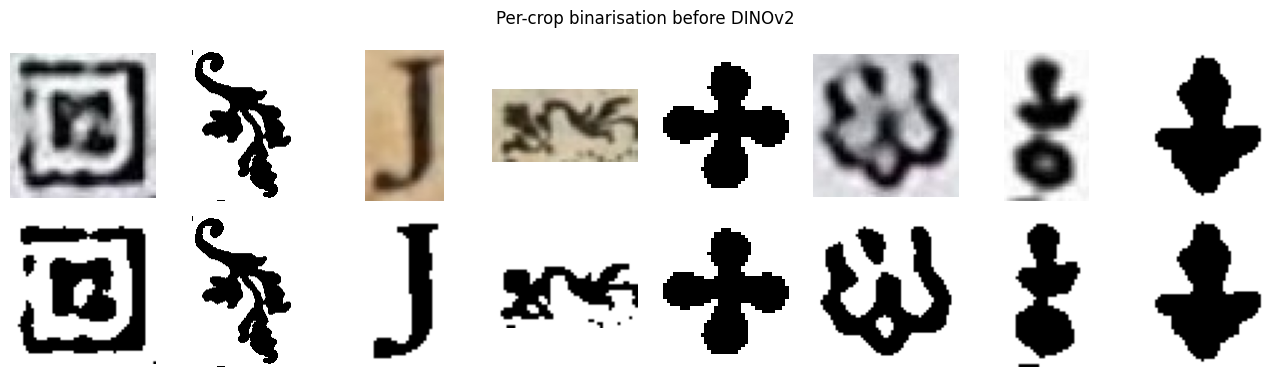

Wrote <project>/feature_extraction_outputs/all_regions_v1_minside24_dinov2_vitb14_binarized_v1_rerun1/figures/preprocessing_sample.png


In [4]:
def binarize_crop(source_image: Image.Image) -> Image.Image:
    grayscale = np.asarray(source_image.convert('L'))
    _, binary = cv2.threshold(
        grayscale, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return Image.fromarray(binary)


def prepare_model_input(source_image: Image.Image) -> torch.Tensor:
    working_image = binarize_crop(source_image) if BINARIZE else source_image.copy()
    working_image = working_image.convert('RGB')
    width, height = working_image.size
    square_size = max(width, height)
    canvas = Image.new('RGB', (square_size, square_size), (255, 255, 255))
    canvas.paste(working_image, ((square_size - width) // 2, (square_size - height) // 2))
    canvas = canvas.resize(
        (IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BICUBIC
    )
    image_array = (
        np.asarray(canvas, dtype=np.float32) / 255.0 - IMAGENET_MEAN
    ) / IMAGENET_STD
    return torch.from_numpy(image_array).permute(2, 0, 1)


class CropDataset(Dataset):
    def __init__(self, crop_paths):
        self.crop_paths = list(crop_paths)

    def __len__(self):
        return len(self.crop_paths)

    def __getitem__(self, index):
        crop_path = PROJECT_DIR / self.crop_paths[index]
        with Image.open(crop_path) as crop_image:
            return prepare_model_input(crop_image)


sample_rows = features_manifest.sample(8, random_state=RANDOM_SEED)
figure, axes = plt.subplots(2, len(sample_rows), figsize=(13, 3.8))
for column_index, sample_row in enumerate(sample_rows.itertuples(index=False)):
    with Image.open(PROJECT_DIR / sample_row.crop_path) as crop_image:
        axes[0, column_index].imshow(crop_image.convert('RGB'))
        axes[1, column_index].imshow(binarize_crop(crop_image), cmap='gray', vmin=0, vmax=255)
    axes[0, column_index].axis('off')
    axes[1, column_index].axis('off')
axes[0, 0].set_ylabel('Raw crop')
axes[1, 0].set_ylabel('Model input')
figure.suptitle('Per-crop binarisation before DINOv2')
figure.tight_layout()
preprocessing_figure_path = FIGURES_DIR / 'preprocessing_sample.png'
figure.savefig(preprocessing_figure_path, dpi=180, bbox_inches='tight')
plt.show()
print('Wrote', preprocessing_figure_path)


## 4. DINOv2 embedding

DINOv2 ViT-B/14 gives us one 768-dimensional CLS representation per crop. We write rows in manifest order, and record progress after every batch so an interrupted run can continue from the last completed row.


In [5]:
embedding_is_complete = METADATA_PATH.exists() and FEATURES_PATH.exists()
if embedding_is_complete:
    with METADATA_PATH.open(encoding='utf-8') as file_handle:
        embedding_metadata = json.load(file_handle)
    assert embedding_metadata['protocol'] == embedding_protocol
    feature_matrix = np.load(FEATURES_PATH, mmap_mode='r')
    assert feature_matrix.shape == (len(features_manifest), MODEL_DIMENSION)
    print('Loaded the complete feature matrix.')
else:
    if PROGRESS_PATH.exists():
        with PROGRESS_PATH.open(encoding='utf-8') as file_handle:
            progress_record = json.load(file_handle)
        assert progress_record['protocol'] == embedding_protocol
        completed_rows = int(progress_record['completed_rows'])
        accumulated_seconds = float(progress_record['elapsed_seconds'])
        feature_matrix = np.lib.format.open_memmap(FEATURES_PATH, mode='r+')
        print(f'Resuming from row {completed_rows:,}.')
    else:
        completed_rows = 0
        accumulated_seconds = 0.0
        feature_matrix = np.lib.format.open_memmap(
            FEATURES_PATH, mode='w+', dtype=np.float32,
            shape=(len(features_manifest), MODEL_DIMENSION),
        )

    model = torch.hub.load(
        'facebookresearch/dinov2', MODEL_NAME, verbose=False
    ).to(DEVICE).eval()
    remaining_paths = features_manifest.crop_path.iloc[completed_rows:]
    data_loader = DataLoader(
        CropDataset(remaining_paths),
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        shuffle=False,
        pin_memory=(DEVICE == 'cuda'),
    )
    run_started = time.perf_counter()
    current_row = completed_rows
    with torch.inference_mode():
        for image_batch in tqdm(data_loader, desc='DINOv2 embeddings'):
            image_batch = image_batch.to(DEVICE, non_blocking=True)
            batch_features = model(image_batch).detach().cpu().numpy().astype(np.float32)
            next_row = current_row + len(batch_features)
            feature_matrix[current_row:next_row] = batch_features
            feature_matrix.flush()
            current_row = next_row
            elapsed_seconds = accumulated_seconds + time.perf_counter() - run_started
            temporary_progress_path = PROGRESS_PATH.with_suffix('.tmp')
            with temporary_progress_path.open('w', encoding='utf-8') as file_handle:
                json.dump({
                    'protocol': embedding_protocol,
                    'completed_rows': current_row,
                    'elapsed_seconds': elapsed_seconds,
                }, file_handle, indent=2)
            temporary_progress_path.replace(PROGRESS_PATH)

    assert current_row == len(features_manifest)
    total_seconds = accumulated_seconds + time.perf_counter() - run_started
    embedding_metadata = {
        'protocol': embedding_protocol,
        'results': {
            'feature_rows': int(len(features_manifest)),
            'feature_dimension': MODEL_DIMENSION,
            'elapsed_seconds': total_seconds,
            'images_per_second': len(features_manifest) / total_seconds,
            'device': DEVICE,
        },
    }
    with METADATA_PATH.open('w', encoding='utf-8') as file_handle:
        json.dump(embedding_metadata, file_handle, indent=2)
    feature_matrix = np.load(FEATURES_PATH, mmap_mode='r')
    print('Completed DINOv2 embedding.')

print('Feature matrix:', feature_matrix.shape, feature_matrix.dtype)


Resuming from row 20,672.


Completed DINOv2 embedding.
Feature matrix: (21750, 768) float32


## 5. Validate the feature space

We start with structural checks: row count, dimensionality, finite values, and non-zero feature norms. A lightweight format probe then estimates how much scan modality remains predictable after binarisation. This diagnostic does not measure fleuron-recognition accuracy. The probe below balances the two scan formats (up to 6,000 crops each) and obtains 79.4% accuracy against a 50% baseline, showing that substantial format information remains. Because the current notebook does not retain a matched raw-embedding probe, this result does not by itself quantify how much binarisation reduced the confound.


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

features = np.asarray(feature_matrix)
assert features.shape == (len(features_manifest), MODEL_DIMENSION)
assert np.isfinite(features).all()
feature_norms = np.linalg.norm(features, axis=1)
assert (feature_norms > 0).all()
normalised_features = features / feature_norms[:, None]

embedding_summary = pd.DataFrame([{
    'feature_rows': len(features),
    'feature_dimension': features.shape[1],
    'mean_l2_norm': float(feature_norms.mean()),
    'std_l2_norm': float(feature_norms.std()),
    'minimum_l2_norm': float(feature_norms.min()),
    'maximum_l2_norm': float(feature_norms.max()),
    'finite_values': bool(np.isfinite(features).all()),
}])
embedding_summary.to_csv(SUMMARY_PATH, index=False)

file_format = (features_manifest.filename.str.lower()
               .str.rsplit('.', n=1).str[-1].replace({'jpeg': 'jpg'}))
format_frame = pd.DataFrame({
    'index': np.arange(len(file_format)), 'format': file_format
})
probe_rows = []
for format_name, format_subset in format_frame.groupby('format'):
    sample_size = min(len(format_subset), 6000)
    probe_rows.extend(
        format_subset.sample(sample_size, random_state=RANDOM_SEED).to_dict('records')
    )
probe_frame = pd.DataFrame(probe_rows).sample(frac=1, random_state=RANDOM_SEED)
probe_indices = probe_frame['index'].to_numpy(dtype=int)
probe_labels = (probe_frame['format'] == 'bmp').astype(int).to_numpy()
majority_baseline = max(probe_labels.mean(), 1 - probe_labels.mean())
format_accuracy = cross_val_score(
    LogisticRegression(max_iter=1000, solver='liblinear'),
    normalised_features[probe_indices], probe_labels, cv=3,
).mean()
format_diagnostic = pd.DataFrame([{
    'probe_rows': len(probe_indices),
    'format_accuracy': format_accuracy,
    'majority_baseline': majority_baseline,
    'binarized': BINARIZE,
}])
format_diagnostic.to_csv(FORMAT_DIAGNOSTIC_PATH, index=False)

display(embedding_summary)
display(format_diagnostic)


,feature_rows,feature_dimension,mean_l2_norm,std_l2_norm,minimum_l2_norm,maximum_l2_norm,finite_values
0,21750,768,47.279873,1.677098,39.801731,52.426292,True


,probe_rows,format_accuracy,majority_baseline,binarized
0,12000,0.793917,0.5,True


## 6. Nearest-neighbour visual check

For eight deterministic query crops, we display the five most similar DINOv2 vectors. Useful neighbours should show the same fleuron or a related motif, not just similar background tone.


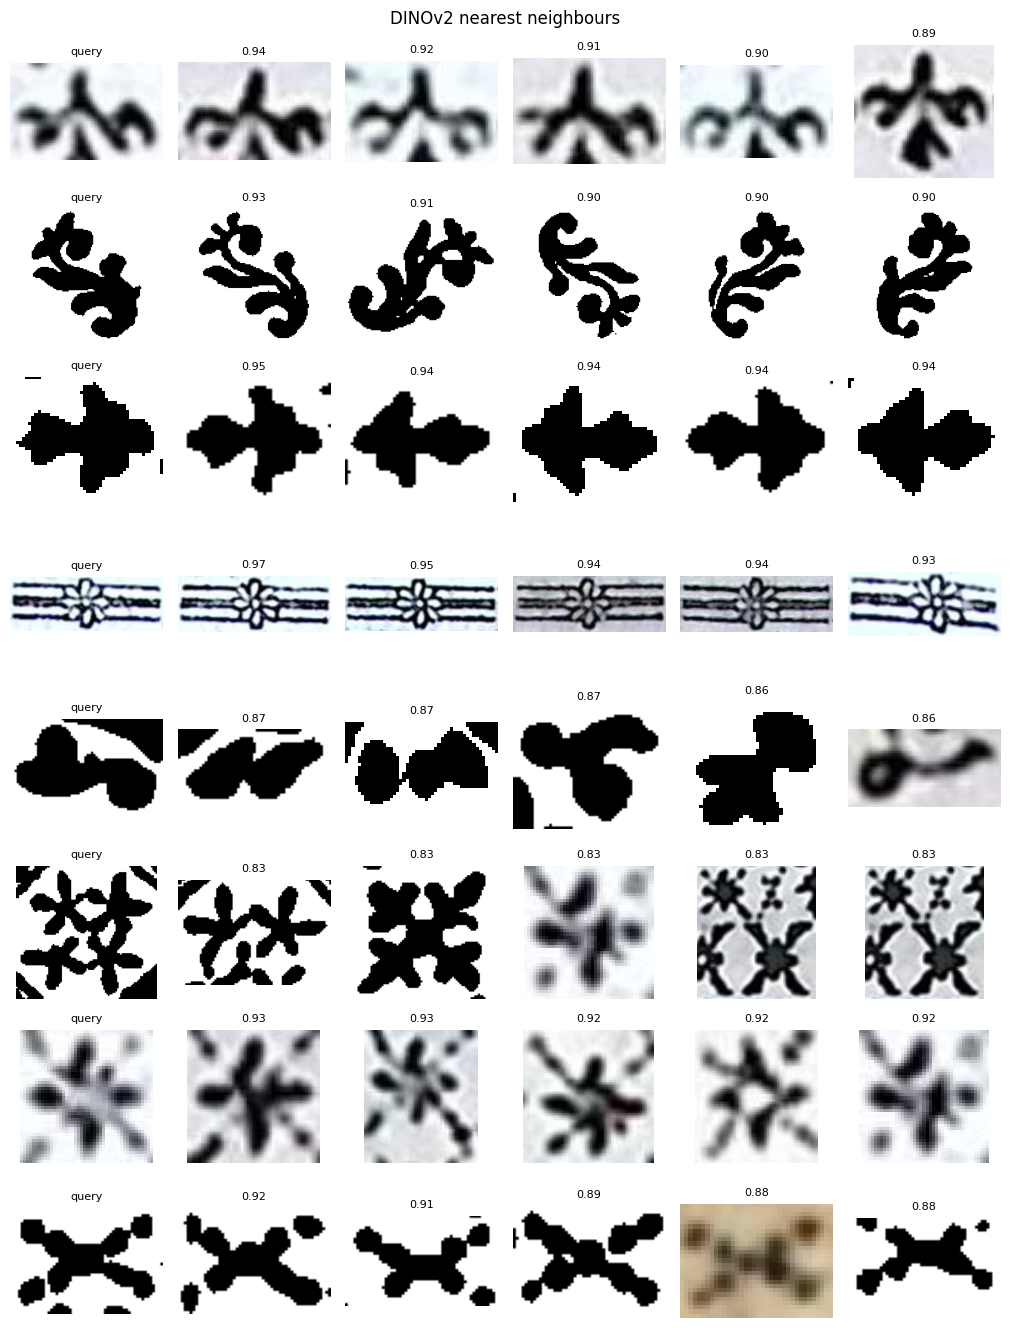

Wrote <project>/feature_extraction_outputs/all_regions_v1_minside24_dinov2_vitb14_binarized_v1_rerun1/figures/nearest_neighbours.png


In [7]:
random_generator = np.random.default_rng(RANDOM_SEED)
query_indices = random_generator.choice(len(normalised_features), 8, replace=False)
neighbor_count = 5
figure, axes = plt.subplots(
    len(query_indices), neighbor_count + 1,
    figsize=((neighbor_count + 1) * 1.7, len(query_indices) * 1.7),
)
for row_index, query_index in enumerate(query_indices):
    similarity_scores = normalised_features @ normalised_features[query_index]
    neighbor_indices = np.argsort(-similarity_scores)[:neighbor_count + 1]
    for column_index, feature_index in enumerate(neighbor_indices):
        axis = axes[row_index, column_index]
        with Image.open(PROJECT_DIR / features_manifest.loc[feature_index, 'crop_path']) as crop_image:
            axis.imshow(crop_image.convert('RGB'))
        axis.set_title(
            'query' if column_index == 0 else f'{similarity_scores[feature_index]:.2f}',
            fontsize=8,
        )
        axis.axis('off')
figure.suptitle('DINOv2 nearest neighbours')
figure.tight_layout()
neighbor_figure_path = FIGURES_DIR / 'nearest_neighbours.png'
figure.savefig(neighbor_figure_path, dpi=180, bbox_inches='tight')
plt.show()
print('Wrote', neighbor_figure_path)


## 7. Two-dimensional overview

UMAP provides a visual overview of the feature space under cosine distance. It is not used for
clustering: graph methods use the L2-normalised 768-dimensional vectors and the selected HDBSCAN
run uses a 50-dimensional PCA projection. The two-dimensional map
preserves only a minority of true neighbourhoods and is read as a picture, not as a substrate.

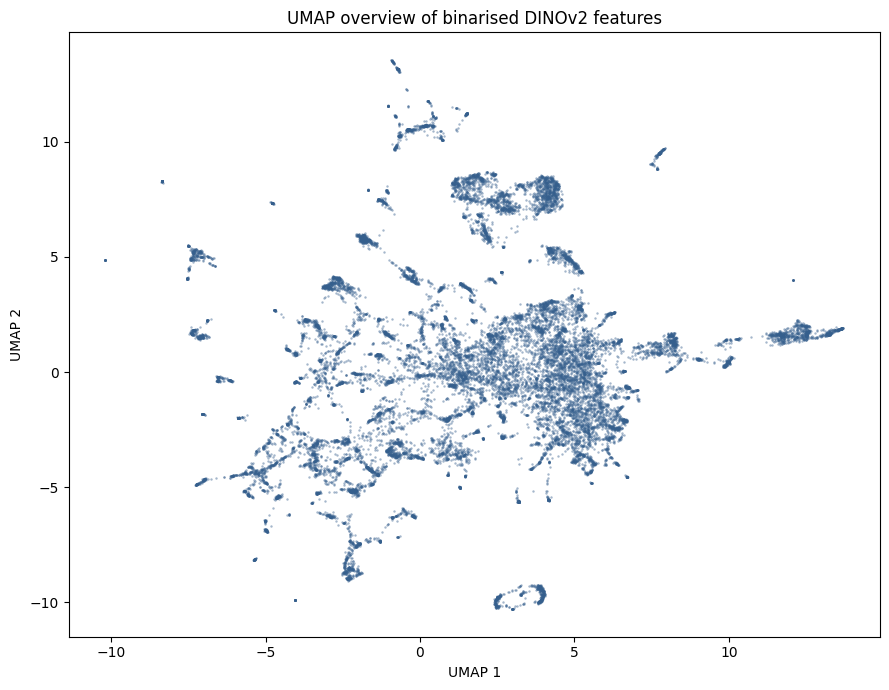

Wrote <project>/feature_extraction_outputs/all_regions_v1_minside24_dinov2_vitb14_binarized_v1_rerun1/umap_2d.npy
Wrote <project>/feature_extraction_outputs/all_regions_v1_minside24_dinov2_vitb14_binarized_v1_rerun1/figures/umap_overview.png


In [8]:
import umap

if UMAP_PATH.exists():
    umap_coordinates = np.load(UMAP_PATH)
else:
    umap_coordinates = umap.UMAP(
        n_neighbors=15, min_dist=0.1, metric='cosine',
        random_state=RANDOM_SEED, low_memory=True,
    ).fit_transform(normalised_features).astype(np.float32)
    np.save(UMAP_PATH, umap_coordinates)
assert umap_coordinates.shape == (len(features_manifest), 2)

figure, axis = plt.subplots(figsize=(9, 7))
axis.scatter(
    umap_coordinates[:, 0], umap_coordinates[:, 1],
    color='#355f8d', s=3, alpha=0.45, linewidths=0,
)
axis.set_title('UMAP overview of binarised DINOv2 features')
axis.set_xlabel('UMAP 1')
axis.set_ylabel('UMAP 2')
figure.tight_layout()
umap_figure_path = FIGURES_DIR / 'umap_overview.png'
figure.savefig(umap_figure_path, dpi=180, bbox_inches='tight')
plt.show()
print('Wrote', UMAP_PATH)
print('Wrote', umap_figure_path)


## 8. Output for clustering

```text
feature_extraction_outputs/all_regions_v1_minside24_dinov2_vitb14_binarized_v1/
├── dino_features_binarized.npy
├── features_manifest.csv
├── embedding_metadata.json
├── embedding_summary.csv
├── format_diagnostic.csv
├── umap_2d.npy
└── figures/
```

`2_PairBenchmark.ipynb` should use `dino_features_binarized.npy` and `features_manifest.csv`. The feature matrix must be L2-normalised before cosine-based clustering; the saved UMAP coordinates are intended only for visualisation.

**What this notebook establishes.** The chapter carries forward 21,750 row-aligned embeddings; 98.8% of those crops have a counterpart under Chapter 1's frozen segmentation configuration. Binarisation reduces, but does not eliminate, scan-format information. The balanced probe shown above reports 79.4% format accuracy against a 50% baseline. Nearest-neighbour sheets are a qualitative sanity check, while UMAP is only an overview and supplies no clustering evidence. The next notebook constructs the human reference needed to turn this representation into an evaluated grouping task.
